In [94]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
from rich import print
import xarray as xr
import shutil
import json
import matplotlib.pyplot as plt

import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

from scipy.interpolate import interp1d

In [89]:
data_path = Path.home() / "BEP-beau/BEP/data" / "mohembo_daily_water_discharge_data.csv"
data = pd.read_csv(data_path, index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m^3/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.columns = ['Yearly volume (Mm^3)']

forcing_path_CMIP = Path.home() / "BEP-beau/BEP/code/CMIP" / "CMIP6_future" 
ssp126_location = forcing_path_CMIP / "SSP126" / "work" / "diagnostic" / "script"
SSP126_CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp126_location)

In [92]:
Area_km2 = 173696.852

def mmday_to_m3s(Q_sim_mmday, area_km2):
    return (Q_sim_mmday * area_km2) / 86.4

def quantile_mapping(observed, modelled, n):
    quantiles = np.linspace(0, 1, n)
    observed_sorted = np.sort(observed)
    modelled_sorted = np.sort(modelled)

    observed_interpolated = interp1d(np.linspace(0, 1, len(observed_sorted)), observed_sorted, bounds_error=False, fill_value="extrapolate")
    modelled_interpolated = interp1d(np.linspace(0, 1, len(modelled_sorted)), modelled_sorted, bounds_error=False, fill_value="extrapolate")

    observed_on_quantiles = observed_interpolated(quantiles)
    modelled_on_quantiles = modelled_interpolated(quantiles)

    mapping_function = interp1d(modelled_on_quantiles, observed_on_quantiles, bounds_error=False, fill_value="extrapolate")

    return mapping_function

In [62]:
parameters = [7.00392414e+00, 4.12282990e-01, 2.24893758e+03, 2.73819672e+00,
       1.84946158e-01, 2.24829623e+01, 1.49246751e-02, 6.55485347e-04,
       3.72295856e-01]
s_0 = np.array([0,  100,  0,  5,  0])

In [124]:
model = ewatercycle.models.HBV(forcing=SSP126_CMIP_forcing)
config_file, _ = model.setup(parameters=parameters, initial_storage=s_0)
model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()

In [125]:
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")
Q_model_pd = Q_model_pd[Q_model_pd.index >= '2030-01-01']
Q_model_pd = Q_model_pd.sort_index()

qm_func_daily = quantile_mapping(data_daily['Discharge (m^3/s)'], Q_model_pd, 1000)
CMIP_corrected_daily = qm_func_daily(Q_model_pd)
CMIP_corrected_daily = pd.DataFrame({'Corrected': CMIP_corrected_daily}, index=Q_model_pd.index)

Q_model_pd_volume = (CMIP_corrected_daily * 3600 * 24).resample('YE').sum() / 1e6

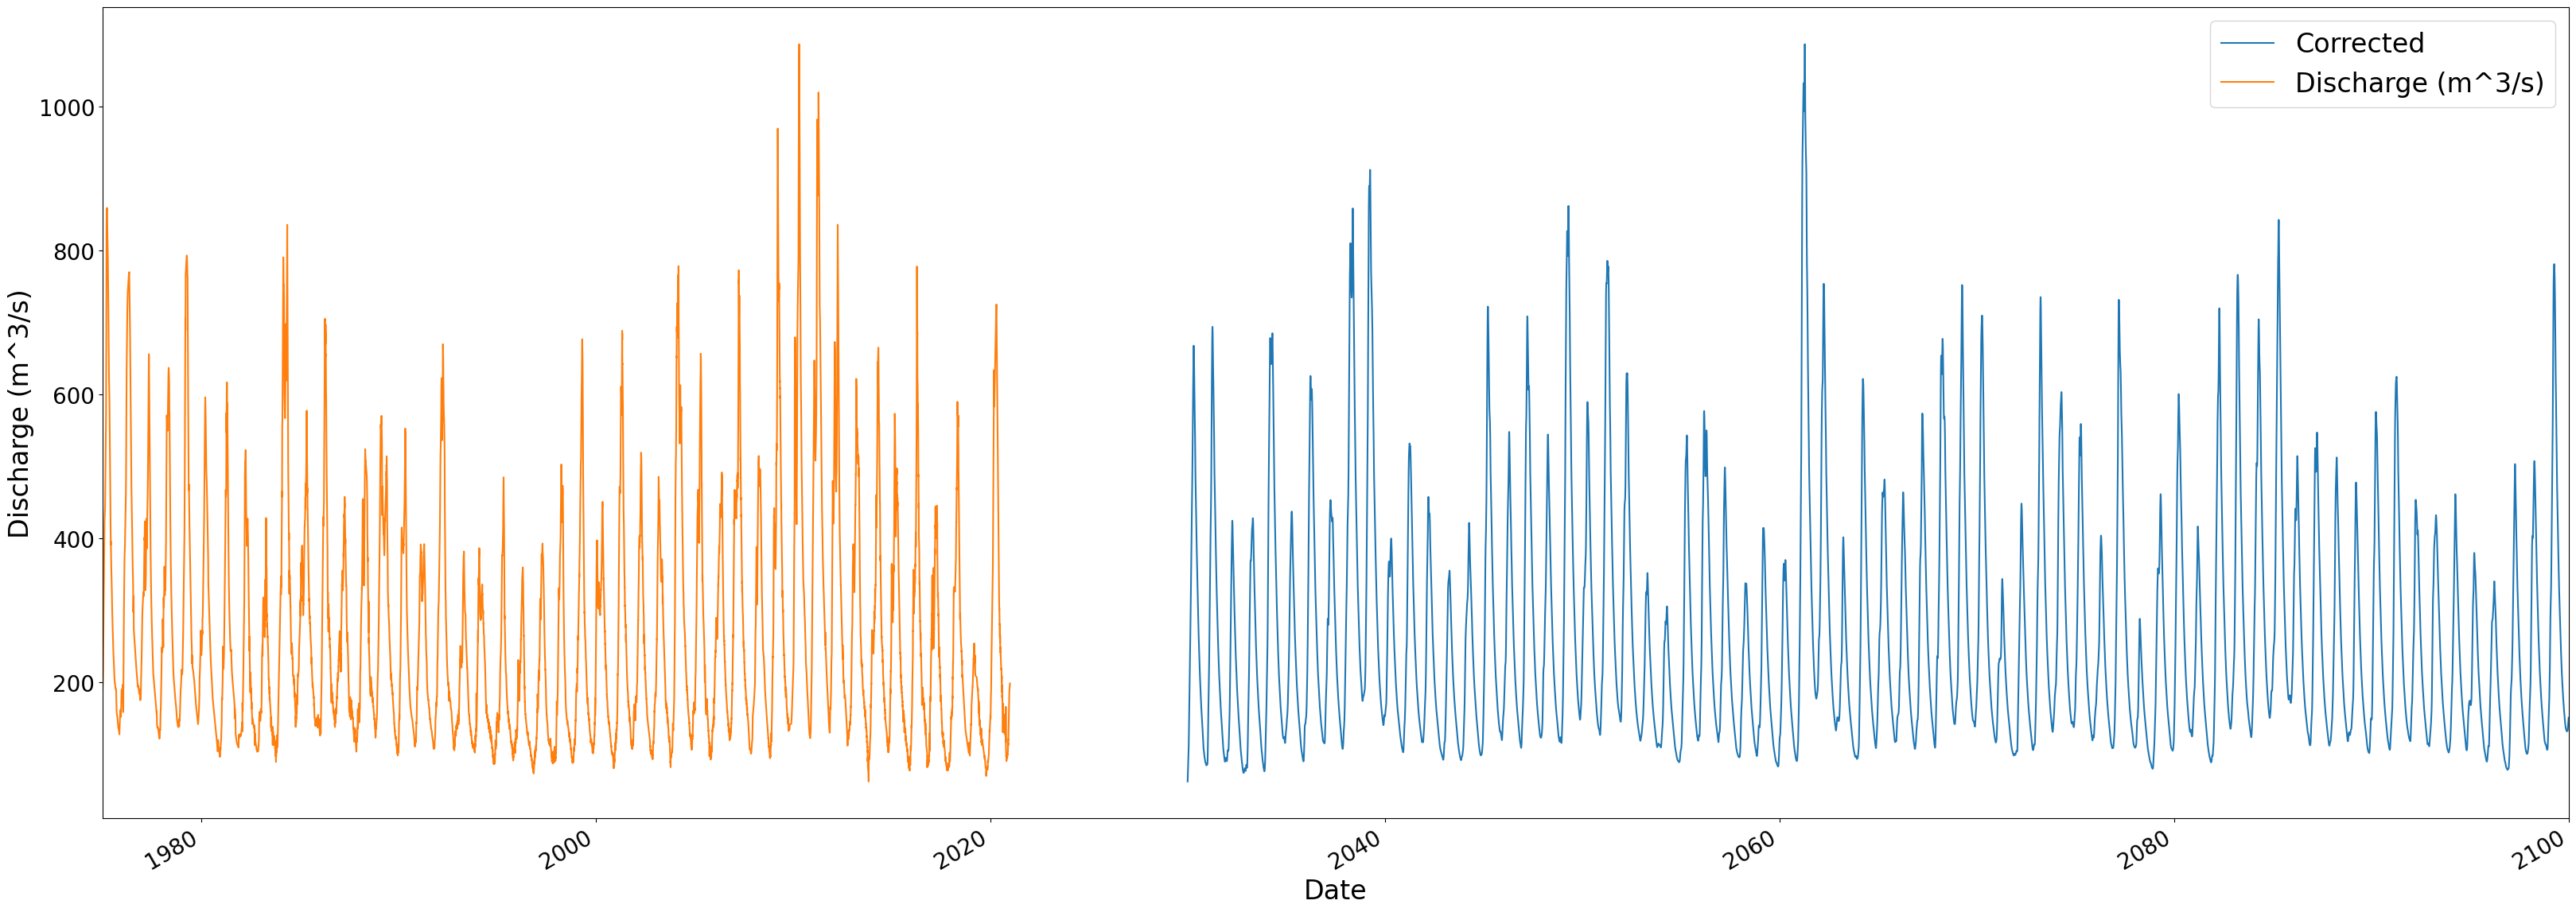

In [126]:
fig, ax = plt.subplots(figsize=(40, 15))
CMIP_corrected_daily.plot(ax=ax)
data_daily.plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
plt.xlim('1975', '2100')
plt.legend(fontsize=24);

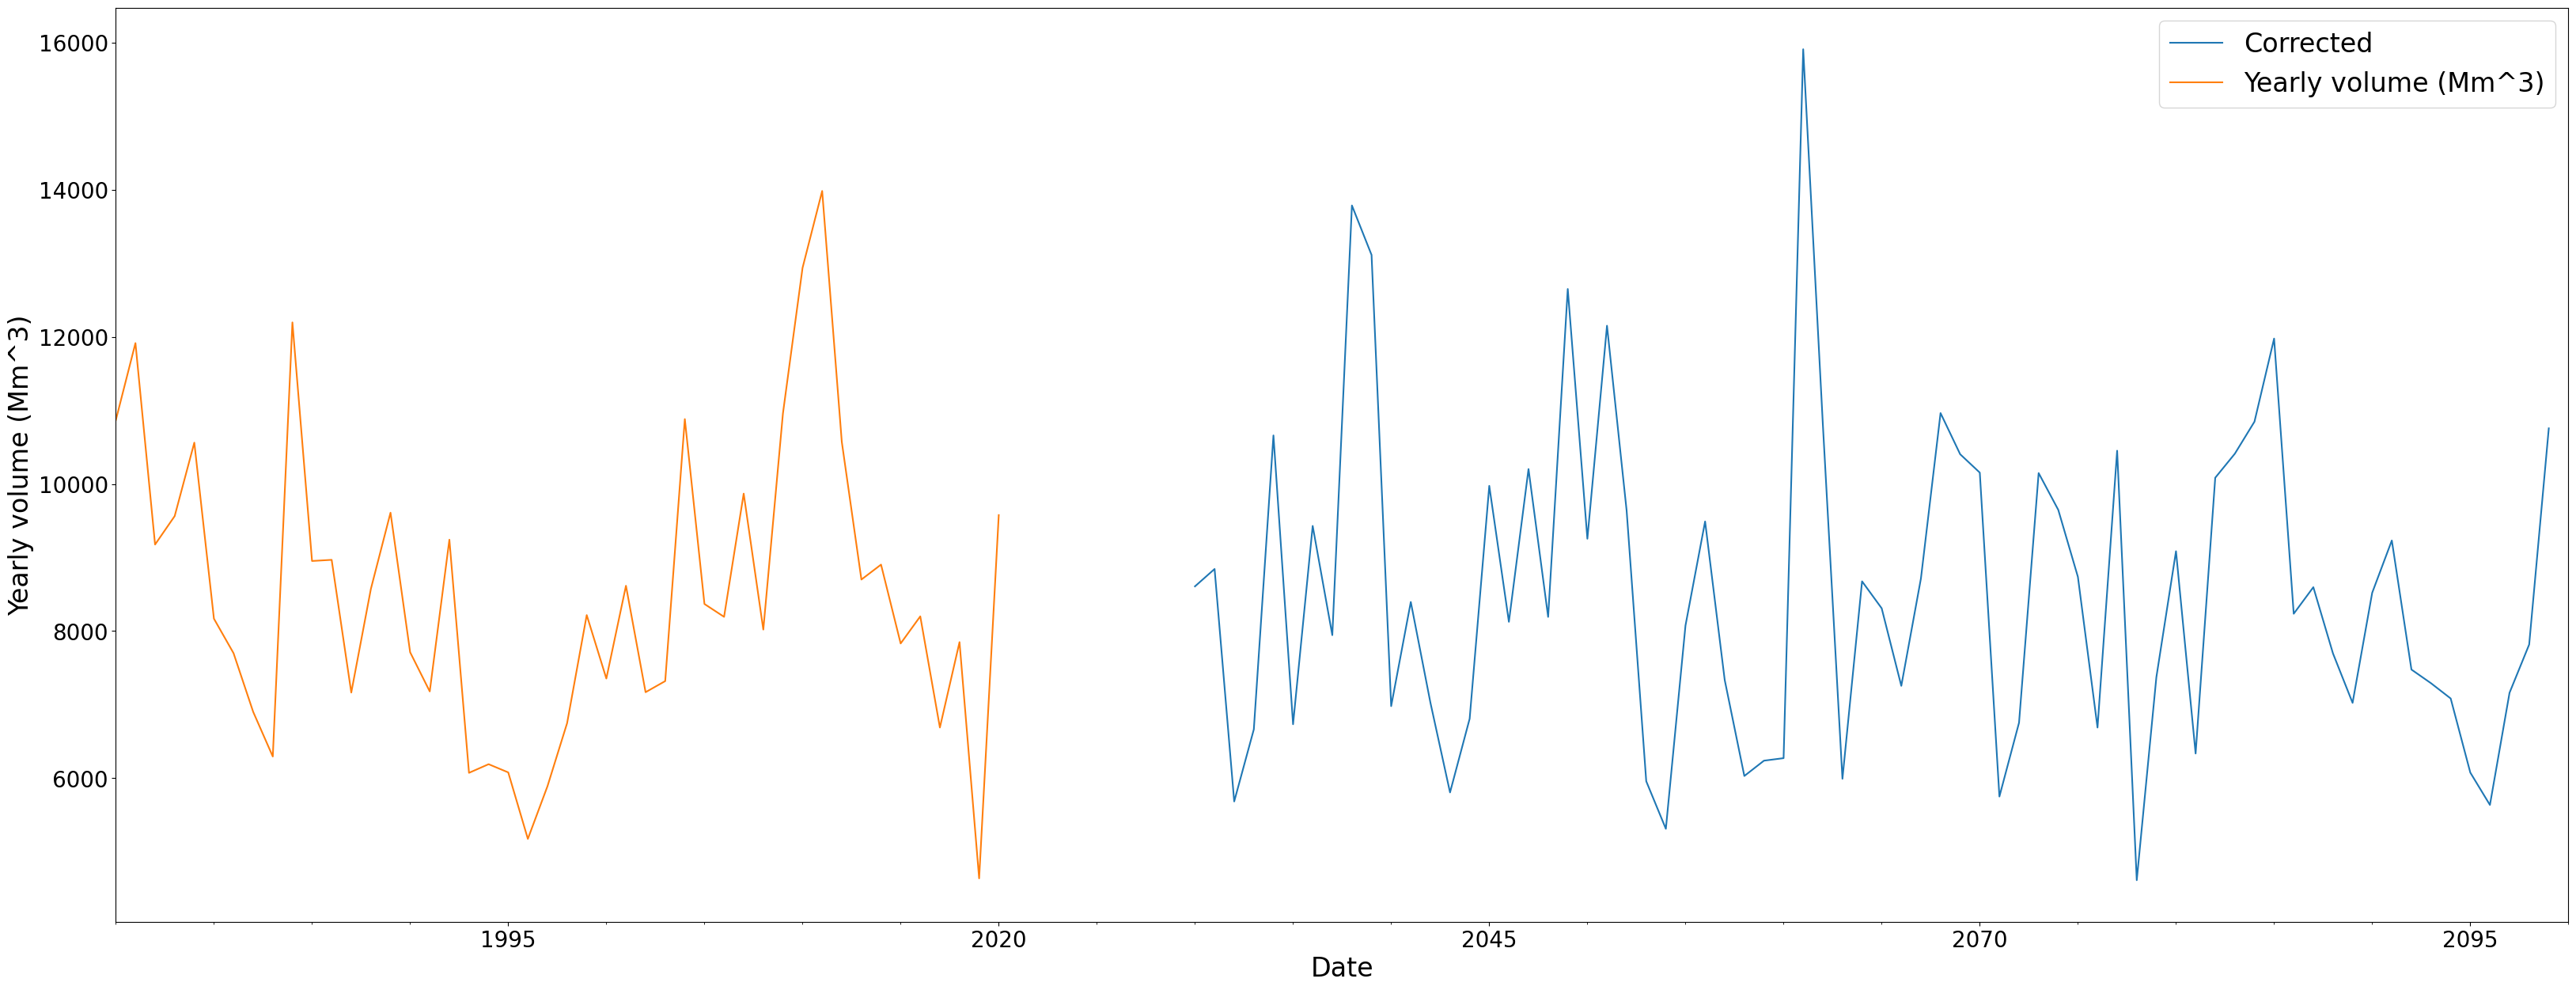

In [127]:
fig, ax = plt.subplots(figsize=(40, 15))
Q_model_pd_volume.plot(ax=ax)
yearly_volume.plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=24)
plt.xlim('1975', '2100')
plt.legend(fontsize=24);

In [128]:
CMIP_corrected_daily.to_csv("SSP126_daily.csv")
Q_model_pd_volume.to_csv("SSP126_yearly.csv")